# Polecenia

Proszę wybrać ulubiony język programowania, wygenerować macierze losowe o wartościach z przedziału otwartego (0.00000001,1.0) i zaimplementować

1. Rekurencyjne mnożenie macierzy metodą Binét’a

2. Rekurencyjne mnożenie macierzy metodą Strassena

3. Mnożenie macierzy metodą AI na podstawie artykułu w Nature

Zakładamy, że macierze są **dowolnego rozmiaru, o takiej samej liczbie wierszy i kolumn**.


# Rozwiązanie w języku Python

Wykorzystano **Python** w wersji `3.12.7` oraz bibliotekę **NumPy** w wersji `2.1.2`

Porównanie wydajności przeprowadzono na procesorze `Intel(R) Core(TM) i7-1165G7` pod kontrolą systemu `5.15.153.1-microsoft-standard-WSL2`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

## Rekurencyjne mnożenie macierzy metodą Binét’a

### Opis metody

Algorytm będzie opierał się na podziale macierzy na bloki, następnie rekurencyjnym pomnożeniu poszczególnych bloków i ostatecznie połączeniu ich w całość.

Posiadając dwie macierze $A$, $B$ o wymiarze $n \times n$, podzielimi je na bloki:
$$ A =  \begin{bmatrix} A_{11} & A_{12} \\ A_{21} & A_{22} \end{bmatrix} $$
$$ B =  \begin{bmatrix} B_{11} & B_{12} \\ B_{21} & B_{22} \end{bmatrix} $$
macierz wynikowa $C = A \cdot B$, będzie postaci:
$$ C =  \begin{bmatrix} C_{11} & C_{12} \\ C_{21} & C_{22} \end{bmatrix} = \begin{bmatrix} (A_{11} B_{11} + A_{12} B_{21}) & (A_{11} B_{12} + A_{12} B_{22}) \\ (A_{21} B_{11} + A_{22} B_{21}) & (A_{21} B_{12} + A_{22} B_{22}) \end{bmatrix} $$
czyli w każdym kroku rekurencyjnym wykonujemy **8 mnożeń** i **4 dodawania**.

In [2]:
def split_matrix(M):
    if M.shape[0] % 2 != 0:
        # Pad with zeros to make n even
        M = np.pad(M, ((0, 1), (0, 1)), 'constant')
    n = M.shape[0] // 2
    return M[:n, :n], M[:n, n:], M[n:, :n], M[n:, n:]

In [3]:
def binet(A, B, debug=False):
    n = A.shape[0]
    if n == 1:
        return A * B
    else:
        A11, A12, A21, A22 = split_matrix(A)
        B11, B12, B21, B22 = split_matrix(B)

        C11 = binet(A11, B11, debug=debug) + binet(A12, B21, debug=debug)
        C12 = binet(A11, B12, debug=debug) + binet(A12, B22, debug=debug)
        C21 = binet(A21, B11, debug=debug) + binet(A22, B21, debug=debug)
        C22 = binet(A21, B12, debug=debug) + binet(A22, B22, debug=debug)

        C = np.vstack((np.hstack((C11, C12)), np.hstack((C21, C22))))[:n, :n]

        if debug:
            global binet_additions, binet_multiplications
            binet_additions += 4
            binet_multiplications += 8

        return C

## Rekurencyjne mnożenie macierzy metodą Strassena

### Opis metody

Algorytm będzie opierał się na podziale macierzy na bloki, następnie rekurencyjnym pomnożeniu poszczególnych bloków i ostatecznie połączeniu ich w całość identycznie jak w metodzie Binét’a, ale wynikowa macierz będzie obliczana w inny sposób.

Posiadając dwie macierze $A$, $B$ o wymiarze $n \times n$, podzielimi je na bloki:
$$ A =  \begin{bmatrix} A_{11} & A_{12} \\ A_{21} & A_{22} \end{bmatrix} $$
$$ B =  \begin{bmatrix} B_{11} & B_{12} \\ B_{21} & B_{22} \end{bmatrix} $$
macierz wynikowa $C = A \cdot B$, będzie postaci:
$$ \begin{matrix}
P_1 = (A_{11} + A_{22}) \cdot (B_{11} + B_{22}) \\
P_2 = (A_{21} + A_{22}) \cdot B_{11} \\
P_3 = A_{11} \cdot (B_{12} - B_{22}) \\
P_4 = A_{22} \cdot (B_{21} - B_{11}) \\
P_5 = (A_{11} + A_{12}) \cdot B_{22} \\
P_6 = (A_{21} - A_{11}) \cdot (B_{11} + B_{12}) \\
P_7 = (A_{12} - A_{22}) \cdot (B_{21} + B_{22})
\end{matrix} $$

$$ C =  \begin{bmatrix}
C_{11} & C_{12} \\ C_{21} & C_{22} 
\end{bmatrix} = 
\begin{bmatrix} 
(P_1 + P_4 - P_5 + P_7) & (P_3 + P_5) \\
(P_2 + P_4) & (P_1 - P_2 + P_3 + P_6)
\end{bmatrix} $$
czyli w każdym kroku rekurencyjnym wykonujemy **7 mnożeń** i **18 dodawań**.

In [4]:
def strassen(A, B, debug=False):
    n = A.shape[0]
    if n == 1:
        return A * B
    else:
        A11, A12, A21, A22 = split_matrix(A)
        B11, B12, B21, B22 = split_matrix(B)

        P1 = strassen(A11 + A22, B11 + B22, debug=debug)
        P2 = strassen(A21 + A22, B11, debug=debug)
        P3 = strassen(A11, B12 - B22, debug=debug)
        P4 = strassen(A22, B21 - B11, debug=debug)
        P5 = strassen(A11 + A12, B22, debug=debug)
        P6 = strassen(A21 - A11, B11 + B12, debug=debug)
        P7 = strassen(A12 - A22, B21 + B22, debug=debug)

        C = np.vstack(
            (
                np.hstack((P1 + P4 - P5 + P7, P3 + P5)),
                np.hstack((P2 + P4, P1 + P3 - P2 + P6)),
            )
        )[:n, :n]

        if debug:
            global strassen_additions, strassen_multiplications
            strassen_additions += 18
            strassen_multiplications += 7

        return C

## Mnożenie macierzy metodą AI na podstawie artykułu w Nature

### Opis metody

[deepmind.google/discover/blog/discovering-novel-algorithms-with-alphatensor/](https://deepmind.google/discover/blog/discovering-novel-algorithms-with-alphatensor/)

In [5]:
def deepmind(A, B, debug=False):
    h = np.empty(76)
    c = np.zeros((4,5))
    a, b = A, B
    
    h[0] = (a[2,1]) * (-b[1,0] - b[1,4] - b[2,0])
    h[1] = (a[1,1] + a[1,4] - a[2,4]) * (-b[1,4] - b[4,0])
    h[2] = (-a[2,0] - a[3,0] + a[3,1]) * (-b[0,0] + b[1,4])
    h[3] = (a[0,1] + a[0,3] + a[2,3]) * (-b[1,4] - b[3,0])
    h[4] = (a[0,4] + a[1,1] + a[1,4]) * (-b[1,3] + b[4,0])
    h[5] = (-a[1,1] - a[1,4] - a[3,4]) * (b[1,2] + b[4,0])
    h[6] = (-a[0,0] + a[3,0] - a[3,1]) * (b[0,0] + b[1,3])
    h[7] = (a[2,1] - a[2,2] - a[3,2]) * (-b[1,2] + b[2,0])
    h[8] = (-a[0,1] - a[0,3] + a[3,3]) * (b[1,2] + b[3,0])
    h[9] = (a[1,1] + a[1,4]) * (b[4,0])
    h[10] = (-a[1,0] - a[3,0] + a[3,1]) * (-b[0,0] + b[1,1])
    h[11] = (a[3,0] - a[3,1]) * (b[0,0])
    h[12] = (a[0,1] + a[0,3] + a[1,3]) * (b[1,1] + b[3,0])
    h[13] = (a[0,2] - a[2,1] + a[2,2]) * (b[1,3] + b[2,0])
    h[14] = (-a[0,1] - a[0,3]) * (b[3,0])
    h[15] = (-a[2,1] + a[2,2]) * (b[2,0])
    h[16] = (a[0,1] + a[0,3] - a[1,0] + a[1,1] - a[1,2] + a[1,3] - a[2,1] + a[2,2] - a[3,0] + a[3,1]) * (b[1,1])
    h[17] = (a[1,0]) * (b[0,0] + b[0,1] + b[4,1])
    h[18] = (-a[1,2]) * (b[2,0] + b[2,1] + b[4,1])
    h[19] = (-a[0,4] + a[1,0] + a[1,2] - a[1,4]) * (-b[0,0] - b[0,1] + b[0,3] - b[4,1])
    h[20] = (a[1,0] + a[1,2] - a[1,4]) * (b[4,1])
    h[21] = (a[0,2] - a[0,3] - a[1,3]) * (b[0,0] + b[0,1] - b[0,3] - b[2,0] - b[2,1] + b[2,3] + b[3,3])
    h[22] = (a[0,2]) * (-b[2,0] + b[2,3] + b[3,3])
    h[23] = (a[0,4]) * (-b[3,3] - b[4,0] + b[4,3])
    h[24] = (-a[0,0]) * (b[0,0] - b[0,3])
    h[25] = (-a[0,2] + a[0,3] + a[0,4]) * (b[3,3])
    h[26] = (a[0,2] - a[2,0] + a[2,2]) * (b[0,0] - b[0,3] + b[0,4] + b[2,4])
    h[27] = (-a[2,3]) * (-b[2,4] - b[3,0] - b[3,4])
    h[28] = (a[2,0]) * (b[0,0] + b[0,4] + b[2,4])
    h[29] = (a[2,0] - a[2,2] + a[2,3]) * (b[2,4])
    h[30] = (-a[0,3] - a[0,4] - a[2,3]) * (-b[3,3] - b[4,0] + b[4,3] - b[4,4])
    h[31] = (a[1,0] + a[3,0] + a[3,3]) * (b[0,2] - b[3,0] - b[3,1] - b[3,2])
    h[32] = (a[3,2]) * (-b[2,0] - b[2,2])
    h[33] = (a[3,3]) * (-b[0,2] + b[3,0] + b[3,2])
    h[34] = (-a[3,4]) * (b[0,2] + b[4,0] + b[4,2])
    h[35] = (a[1,2] - a[1,4] - a[3,4]) * (b[2,0] + b[2,1] + b[2,2] + b[4,1])
    h[36] = (-a[3,0] - a[3,3] + a[3,4]) * (b[0,2])
    h[37] = (-a[1,2] - a[2,0] + a[2,2] - a[2,3]) * (b[2,4] + b[3,0] + b[3,1] + b[3,4])
    h[38] = (-a[2,0] - a[3,0] - a[3,3] + a[3,4]) * (b[0,2] + b[4,0] + b[4,2] + b[4,4])
    h[39] = (-a[0,2] + a[0,3] + a[0,4] - a[3,3]) * (-b[2,0] - b[2,2] + b[2,3] + b[3,3])
    h[40] = (-a[0,0] + a[3,0] - a[3,4]) * (b[0,2] + b[2,0] + b[2,2] - b[2,3] + b[4,0] + b[4,2] - b[4,3])
    h[41] = (-a[1,0] + a[1,4] - a[2,4]) * (-b[0,0] - b[0,1] - b[0,4] + b[3,0] + b[3,1] + b[3,4] - b[4,1])
    h[42] = (a[1,3]) * (b[3,0] + b[3,1])
    h[43] = (a[1,2] + a[2,1] - a[2,2]) * (b[1,1] - b[2,0])
    h[44] = (-a[2,2] + a[2,3] - a[3,2]) * (b[2,4] + b[3,0] + b[3,2] + b[3,4] + b[4,0] + b[4,2] + b[4,4])
    h[45] = (-a[2,4]) * (-b[4,0] - b[4,4])
    h[46] = (a[1,0] - a[1,4] - a[2,0] + a[2,4]) * (b[0,0] + b[0,1] + b[0,4] - b[3,0] - b[3,1] - b[3,4])
    h[47] = (-a[1,2] + a[2,2]) * (b[1,1] + b[2,1] + b[2,4] + b[3,0] + b[3,1] + b[3,4])
    h[48] = (-a[0,0] - a[0,2] + a[0,3] + a[0,4] - a[1,0] - a[1,2] + a[1,3] + a[1,4]) * (-b[0,0] - b[0,1] + b[0,3])
    h[49] = (-a[0,3] - a[1,3]) * (b[1,1] - b[2,0] - b[2,1] + b[2,3] - b[3,1] + b[3,3])
    h[50] = (a[1,1]) * (b[1,0] + b[1,1] - b[4,0])
    h[51] = (a[3,1]) * (b[0,0] + b[1,0] + b[1,2])
    h[52] = (-a[0,1]) * (-b[1,0] + b[1,3] + b[3,0])
    h[53] = (a[0,1] + a[0,3] - a[1,1] - a[1,4] - a[2,1] + a[2,2] - a[3,1] + a[3,2] - a[3,3] - a[3,4]) * (b[1,2])
    h[54] = (a[0,3] - a[3,3]) * (-b[1,2] + b[2,0] + b[2,2] - b[2,3] + b[3,2] - b[3,3])
    h[55] = (a[0,0] - a[0,4] - a[3,0] + a[3,4]) * (b[2,0] + b[2,2] - b[2,3] + b[4,0] + b[4,2] - b[4,3])
    h[56] = (-a[2,0] - a[3,0]) * (-b[0,2] - b[0,4] - b[1,4] - b[4,0] - b[4,2] - b[4,4])
    h[57] = (-a[0,3] - a[0,4] - a[2,3] - a[2,4]) * (-b[4,0] + b[4,3] - b[4,4])
    h[58] = (-a[2,2] + a[2,3] - a[3,2] + a[3,3]) * (b[3,0] + b[3,2] + b[3,4] + b[4,0] + b[4,2] + b[4,4])
    h[59] = (a[1,4] + a[3,4]) * (b[1,2] - b[2,0] - b[2,1] - b[2,2] - b[4,1] - b[4,2])
    h[60] = (a[0,3] + a[2,3]) * (b[0,0] - b[0,3] + b[0,4] - b[1,4] - b[3,3] + b[3,4] - b[4,0] + b[4,3] - b[4,4])
    h[61] = (a[1,0] + a[3,0]) * (b[0,1] + b[0,2] + b[1,1] - b[3,0] - b[3,1] - b[3,2])
    h[62] = (-a[2,2] - a[3,2]) * (-b[1,2] - b[2,2] - b[2,4] - b[3,0] - b[3,2] - b[3,4])
    h[63] = (a[0,0] - a[0,2] - a[0,3] + a[2,0] - a[2,2] - a[2,3]) * (b[0,0] - b[0,3] + b[0,4])
    h[64] = (-a[0,0] + a[3,0]) * (-b[0,2] + b[0,3] + b[1,3] - b[4,0] - b[4,2] + b[4,3])
    h[65] = (a[0,0] - a[0,1] + a[0,2] - a[0,4] - a[1,1] - a[1,4] - a[2,1] + a[2,2] - a[3,0] + a[3,1]) * (b[1,3])
    h[66] = (a[1,4] - a[2,4]) * (b[0,0] + b[0,1] + b[0,4] - b[1,4] - b[3,0] - b[3,1] - b[3,4] + b[4,1] + b[4,4])
    h[67] = (a[0,0] + a[0,2] - a[0,3] - a[0,4] - a[3,0] - a[3,2] + a[3,3] + a[3,4]) * (-b[2,0] - b[2,2] + b[2,3])
    h[68] = (-a[0,2] + a[0,3] - a[1,2] + a[1,3]) * (-b[1,3] - b[2,0] - b[2,1] + b[2,3] - b[4,1] + b[4,3])
    h[69] = (a[1,2] - a[1,4] + a[3,2] - a[3,4]) * (-b[2,0] - b[2,1] - b[2,2])
    h[70] = (-a[2,0] + a[2,2] - a[2,3] + a[2,4] - a[3,0] + a[3,2] - a[3,3] + a[3,4]) * (-b[4,0] - b[4,2] - b[4,4])
    h[71] = (-a[1,0] - a[1,3] - a[3,0] - a[3,3]) * (b[3,0] + b[3,1] + b[3,2])
    h[72] = (a[0,2] - a[0,3] - a[0,4] + a[1,2] - a[1,3] - a[1,4]) * (b[0,0] + b[0,1] - b[0,3] + b[1,3] + b[4,1] - b[4,3])
    h[73] = (a[1,0] - a[1,2] + a[1,3] - a[2,0] + a[2,2] - a[2,3]) * (b[3,0] + b[3,1] + b[3,4])
    h[74] = (-a[0,1] - a[0,3] + a[1,1] + a[1,4] + a[2,0] - a[2,1] - a[2,3] - a[2,4] + a[3,0] - a[3,1]) * (b[1,4])
    h[75] = (a[0,2] + a[2,2]) * (-b[0,0] + b[0,3] - b[0,4] + b[1,3] + b[2,3] - b[2,4])

    c[0,0] = -h[9] + h[11] + h[13] - h[14] - h[15] + h[52] + h[4] - h[65] - h[6]
    c[1,0] = h[9] + h[10] - h[11] + h[12] + h[14] + h[15] - h[16] - h[43] + h[50]
    c[2,0] = h[9] - h[11] + h[14] + h[15] - h[0] + h[1] + h[2] - h[3] + h[74]
    c[3,0] = -h[9] + h[11] - h[14] - h[15] + h[51] + h[53] - h[5] - h[7] + h[8]
    c[0,1] = h[12] + h[14] + h[19] + h[20] - h[21] + h[22] + h[24] - h[42] + h[48] + h[49]
    c[1,1] = -h[10] + h[11] - h[12] - h[14] - h[15] + h[16] + h[17] - h[18] - h[20] + h[42] + h[43]
    c[2,1] = -h[15] - h[18] - h[20] - h[27] - h[28] - h[37] + h[41] + h[43] - h[46] + h[47]
    c[3,1] = h[10] - h[11] - h[17] + h[20] - h[31] + h[32] - h[33] - h[35] + h[61] - h[69]
    c[0,2] = h[14] + h[22] + h[23] + h[33] - h[36] + h[39] - h[40] + h[54] - h[55] - h[8]
    c[1,2] = -h[9] + h[18] + h[31] + h[34] + h[35] + h[36] - h[42] - h[59] - h[5] - h[71]
    c[2,2] = -h[15] - h[27] + h[32] + h[36] - h[38] + h[44] - h[45] + h[62] - h[70] - h[7]
    c[3,2] = h[9] + h[14] + h[15] - h[32] + h[33] - h[34] - h[36] - h[53] + h[5] + h[7] - h[8]
    c[0,3] = -h[9] + h[11] + h[13] - h[15] + h[22] + h[23] + h[24] + h[25] + h[4] - h[65] - h[6]
    c[1,3] = h[9] + h[17] - h[18] + h[19] - h[21] - h[23] - h[25] - h[4] - h[68] + h[72]
    c[2,3] = -h[13] + h[15] - h[22] - h[25] + h[26] + h[28] + h[30] + h[45] - h[57] + h[75]
    c[3,3] = h[11] + h[24] + h[25] - h[32] - h[34] - h[39] + h[40] + h[64] - h[67] - h[6]
    c[0,4] = h[14] + h[23] + h[24] + h[26] - h[27] + h[29] + h[30] - h[3] + h[60] + h[63]
    c[1,4] = -h[9] - h[17] - h[1] - h[29] - h[37] + h[41] - h[42] + h[45] + h[66] + h[73]
    c[2,4] = -h[9] + h[11] - h[14] + h[27] + h[28] - h[1] - h[29] - h[2] + h[45] + h[3] - h[74]
    c[3,4] = -h[11] - h[28] + h[29] - h[33] + h[34] + h[38] + h[2] - h[44] + h[56] + h[58]

    return c

# Raport

In [6]:
RAND_RANGE = (0.00000001, 1.0)
SIZES = list(range(1, 71))
times = {"binet": [], "strassen": []}
operations = {
    "binet_additions": [],
    "binet_multiplications": [],
    "strassen_additions": [],
    "strassen_multiplications": [],
}

In [7]:
for size in SIZES:
    A = np.random.uniform(*RAND_RANGE, (size, size))
    B = np.random.uniform(*RAND_RANGE, (size, size))
    binet_additions, binet_multiplications = 0, 0
    strassen_additions, strassen_multiplications = 0, 0

    start = time.time()
    C = binet(A, B, debug=True)
    times["binet"].append(time.time() - start)
    assert np.allclose(C, A @ B)
    operations["binet_additions"].append(binet_additions)
    operations["binet_multiplications"].append(binet_multiplications)

    start = time.time()
    C = strassen(A, B, debug=True)
    times["strassen"].append(time.time() - start)
    assert np.allclose(C, A @ B)
    operations["strassen_additions"].append(strassen_additions)
    operations["strassen_multiplications"].append(strassen_multiplications)

## Czas wykonania

In [8]:
def plot_matrix_times():
    plt.figure(figsize=(10, 6))
    plt.plot(SIZES, times["binet"], label="binet")
    plt.plot(SIZES, times["strassen"], label="strassen")
    plt.title("Matrix multiplication time")
    plt.xlabel("Matrix size")
    plt.ylabel("Time [s]")
    plt.legend()
    plt.show()

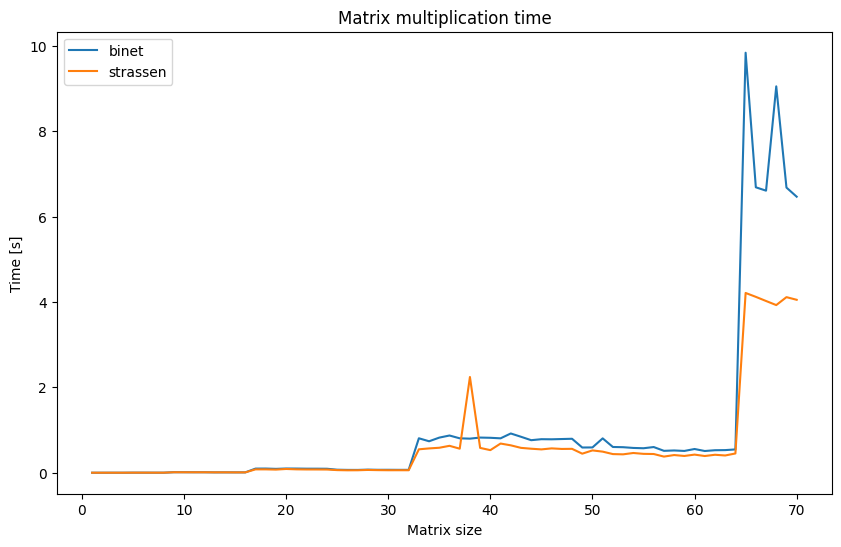

In [9]:
plot_matrix_times()

## Ilość operacji

In [10]:
def plot_matrix_operations():
    plt.figure(figsize=(10, 6))
    plt.plot(SIZES, operations["binet_additions"], label="binet_additions")
    plt.plot(SIZES, operations["binet_multiplications"], label="binet_multiplications")
    plt.plot(SIZES, operations["strassen_additions"], label="strassen_additions")
    plt.plot(SIZES, operations["strassen_multiplications"], label="strassen_multiplications")
    plt.title("Matrix multiplication operations")
    plt.xlabel("Matrix size")
    plt.ylabel("Operations")
    plt.legend()
    plt.show()

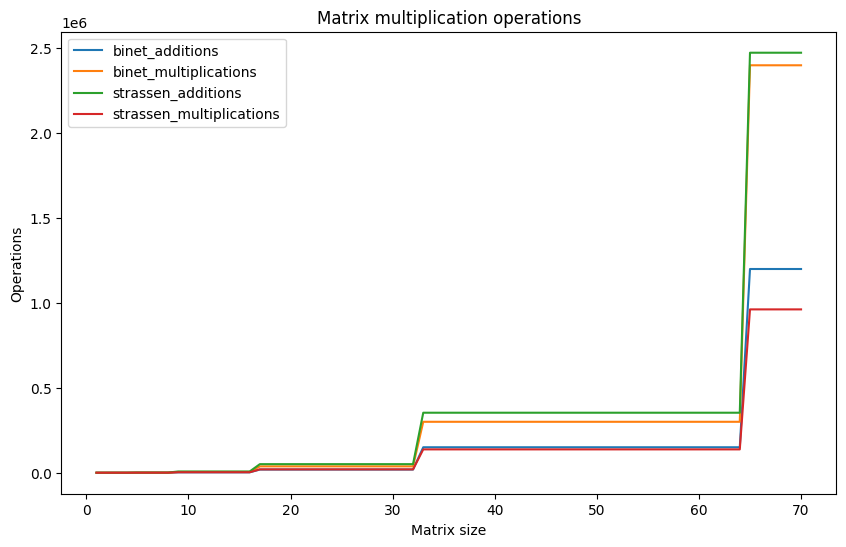

In [11]:
plot_matrix_operations()

## Oszacowana złożoność czasowa

Obie metody (zarówno klasyczna metoda Bineta, jak i metoda Strassena) dzielą macierze rozmiaru $n \times n$ na bloki $n/2 \times n/2$. Z tego wynika, że liczba poziomów rekurencji wynosi $log_2{n}$, ponieważ na każdym poziomie rozmiar macierzy zmniejsza się o połowę.

1. Rekurencyjne mnożenie macierzy metodą klasyczną (Bineta):
      - Mnożenia: Na każdym poziomie wykonujemy $8$ mnożeń bloków, czyli $8^{log_2{n}} = O(n^3)$ mnożeń na wszystkich poziomach.
      - Dodawania: Na każdym poziomie wykonujemy $4$ dodawania bloków, co daje $O(n^2)$ na każdym poziomie i łącznie $O(n^2 log⁡_2{n})$.
      - Łącznie złożoność wynosi $O(n^3)$
2. Rekurencyjne mnożenie macierzy metodą Strassena:
      - Mnożenia: Na każdym poziomie wykonujemy $8$ mnożeń bloków, czyli $7^{log_2{n}} = O(n^{log_2{7}})$ mnożeń na wszystkich poziomach.
      - Dodawania: Na każdym poziomie wykonujemy $18$ dodawań bloków, co daje $O(n^2)$ na każdym poziomie i łącznie $O(n^2 log⁡_2{n})$.
      - Łącznie złożoność wynosi $\approx O(n^{2.807})$

## Sprawdzenie poprawności wyników

W celu sprawdzenia poprawności wyników, porównano wyniki z wynikami uzyskanymi za pomocą funkcji `numpy.dot()`

In [12]:
ABs = [
    (
        np.array([[1, 2], [3, 4]]),
        np.array([[5, 6], [7, 8]]),
    ),
    (
        np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]]),
        np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]]),
    ),
    (
        np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]]),
        np.array([[16, 15, 14, 13], [12, 11, 10, 9], [8, 7, 6, 5], [4, 3, 2, 1]]),
    ),
]

### Binet

In [13]:
for A, B in ABs:
    binet_additions, binet_multiplications = 0, 0
    assert np.array_equal(binet(A, B, debug=True), A @ B)
    print(
        f"Shape:{A.shape[0]}x{B.shape[0]}, Additions: {binet_additions}, Multiplications: {binet_multiplications}"
    )


Shape:2x2, Additions: 4, Multiplications: 8
Shape:3x3, Additions: 36, Multiplications: 72
Shape:4x4, Additions: 36, Multiplications: 72


### Strassen

In [14]:
for A, B in ABs:
    strassen_additions, strassen_multiplications = 0, 0
    assert np.array_equal(strassen(A, B, debug=True), A @ B)
    print(
        f"Shape:{A.shape[0]}x{B.shape[0]}, Additions: {strassen_additions}, Multiplications: {strassen_multiplications}"
    )

Shape:2x2, Additions: 18, Multiplications: 7
Shape:3x3, Additions: 144, Multiplications: 56
Shape:4x4, Additions: 144, Multiplications: 56


### Algorytm AI

In [15]:
A = np.array(
    [
        [1, 2, 3, 4, 5],
        [6, 7, 8, 9, 10],
        [11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20],
    ]
)
B = np.array(
    [
        [1, 2, 3, 4, 5],
        [6, 7, 8, 9, 10],
        [11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20],
        [21, 22, 23, 24, 25],
    ]
)

assert np.array_equal(deepmind(A, B, debug=True), A @ B)